In [17]:

import os

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

import glob


# Set seed for experimental reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Import Dataset

(600,)


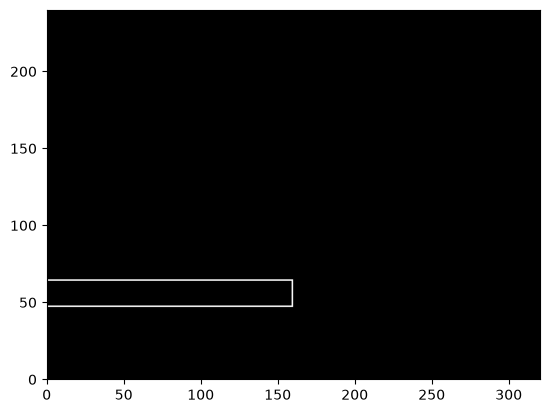

In [ ]:
SAMPLES = 1000
WIDTH = 240 # Change as needed
HEIGHT = 320 # Changed as needed
np.set_printoptions(threshold=np.inf)

def show_screen(axs, screen):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,320,0,240))

label_array = ["circle", "rectangle", "triangle"]
label_to_index = dict((name, index) for index,name in enumerate(label_array))

def get_img(img_path):
    return np.load(img_path)

# Create tuple of whole dataset
def get_ds(data_path):
    labels = np.zeros(SAMPLES*3)
    images = np.zeros((SAMPLES*3, WIDTH, HEIGHT))
    img_paths = list()

    for img_path in glob.glob(F'{data_path}/**/*'):
        img_paths.append(img_path)
        #head, tail = os.path.split(img_path)
        #print(tail.split('-')[0])
    
    random.shuffle(img_paths)
    for i, img_path in enumerate(img_paths):
        images[i] = get_img(img_path)
        head, tail = os.path.split(img_path)
        label_id = tail.split('-')[0]
        labels[i] = label_to_index[label_id]
    
    return images, labels


TRAIN_SPLIT = int(0.6*(SAMPLES*3))
TEST_SPLIT = int(0.2*(SAMPLES*3) + TRAIN_SPLIT)

full_x, full_y = get_ds('data')

x_train, x_test, x_validate = np.split(full_x, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(full_y, [TRAIN_SPLIT, TEST_SPLIT])

show_screen(plt, x_validate[4])
print(label_array[int(y_validate[4])])

#full_x, full_y = get_ds('data')

#circle_x, circle_y = (full_x[:1000], full_y[:1000])
#rectangle_x, rectangle_y = (full_x[1000:2000], full_y[1000:2000])
#triangle_x, triangle_y = (full_x[2000:], full_y[2000:])




#list_ds = tf.data.Dataset.list_files(str(data_dir/'*/*'), shuffle=False)
#list_ds = list_ds.shuffle(data_count, reshuffle_each_iteration=False)

#for f in list_ds.take(5):
#    print(f.numpy())

# Retrieve labels from directories
#class_names = np.array(sorted([item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt"]))
#print(class_names)

# Split data into training and validation
#val_size = int(data_count*0.2)
#train_ds = list_ds.skip(val_size)
#val_ds = list_ds.take(val_size)

# Print length of datasets
#print(tf.data.experimental.cardinality(train_ds).numpy())
#print(tf.data.experimental.cardinality(val_ds).numpy())

#test = np.loadtxt(circles[0])
#print(test)

#def get_label(file_path):
#    yield



